In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/dataset_split_v3.zip /content/
!unzip -q /content/dataset_split_v3.zip -d /content/
!ls /content/dataset_split_v3/

Mounted at /content/drive
test  train  val


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from pathlib import Path
from PIL import Image
import numpy as np
from collections import defaultdict

In [3]:
CONFIG = {
    "train_dir": "/content/dataset_split_v3/train",
    "val_dir": "/content/dataset_split_v3/val",
    "test_dir": "/content/dataset_split_v3/test",
    "image_size": 224,
    "num_classes": 5,
    "batch_size": 256,
    "epochs_stage1": 15,
    "epochs_stage2": 150,
    "lr_stage1": 0.001,
    "lr_stage2": 0.00003,
    "weight_decay": 0.0001,
    "mixup_alpha": 0.2,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')
print("H100 optimizations enabled")

Device: cuda
GPU: NVIDIA H100 80GB HBM3
H100 optimizations enabled


In [4]:
class KneeDataset(Dataset):
    def __init__(self, root_dir, image_size, augment=False):
        self.root_dir = Path(root_dir)
        self.image_size = image_size

        extensions = {".png", ".jpg", ".jpeg"}
        self.samples = []

        for grade_dir in sorted(self.root_dir.iterdir()):
            if not grade_dir.is_dir():
                continue
            label = int(grade_dir.name.replace("Grade_", ""))
            for img_path in grade_dir.iterdir():
                if img_path.suffix.lower() in extensions:
                    self.samples.append((img_path, label))

        if augment:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=3),
                transforms.Resize((image_size + 32, image_size + 32)),
                transforms.RandomCrop(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.2),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=3),
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, label

train_ds = KneeDataset(CONFIG["train_dir"], CONFIG["image_size"], augment=True)
val_ds = KneeDataset(CONFIG["val_dir"], CONFIG["image_size"], augment=False)
test_ds = KneeDataset(CONFIG["test_dir"], CONFIG["image_size"], augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=8, drop_last=True, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 60000, Val: 7500, Test: 7500


In [5]:
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [6]:
class KOAEfficientNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone(self):
        for param in self.backbone.features.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.backbone.features.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

model = KOAEfficientNet(CONFIG["num_classes"]).to(DEVICE)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 224MB/s]


Total params: 18,469,197


In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float('inf')
best_val_acc = 0.0

def train_one_epoch(model, loader, optimizer, use_mixup=False, alpha=0.2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if use_mixup:
            mixed_images, y_a, y_b, lam = mixup_data(images, labels, alpha)
            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (lam * predicted.eq(y_a).sum().item() + (1 - lam) * predicted.eq(y_b).sum().item())
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100.0 * correct / total

def validate(model, loader):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return val_loss / len(loader), 100.0 * correct / total

In [8]:
print("=== STAGE 1: Frozen backbone, head only ===\n")
model.freeze_backbone()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr_stage1"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

for epoch in range(CONFIG["epochs_stage1"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, use_mixup=False)
    val_loss, val_acc = validate(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch [{epoch+1}/{CONFIG['epochs_stage1']}] "
              f"Train: {train_loss:.4f} / {train_acc:.2f}% | "
              f"Val: {val_loss:.4f} / {val_acc:.2f}% | "
              f"LR: {lr:.6f} | Best: {best_val_acc:.2f}%")

print(f"\nStage 1 done. Best val acc: {best_val_acc:.2f}%")

=== STAGE 1: Frozen backbone, head only ===

  Epoch [1/15] Train: 1.2475 / 52.39% | Val: 1.1983 / 55.35% | LR: 0.001000 | Best: 55.35%
  Epoch [5/15] Train: 1.1598 / 57.95% | Val: 1.1506 / 58.81% | LR: 0.001000 | Best: 58.81%
  Epoch [10/15] Train: 1.1407 / 59.18% | Val: 1.1201 / 60.25% | LR: 0.001000 | Best: 60.25%
  Epoch [15/15] Train: 1.1322 / 59.86% | Val: 1.1243 / 59.79% | LR: 0.001000 | Best: 60.57%

Stage 1 done. Best val acc: 60.57%


In [9]:
print("=== STAGE 2: Full fine-tuning with Mixup ===\n")
model.unfreeze_backbone()
optimizer = optim.Adam([
    {"params": model.backbone.features.parameters(), "lr": CONFIG["lr_stage2"]},
    {"params": model.backbone.classifier.parameters(), "lr": CONFIG["lr_stage2"] * 5},
], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs_stage2"], eta_min=1e-7)

patience_counter = 0
patience = 30

for epoch in range(CONFIG["epochs_stage2"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, use_mixup=True, alpha=CONFIG["mixup_alpha"])
    val_loss, val_acc = validate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        lr_bb = optimizer.param_groups[0]['lr']
        lr_head = optimizer.param_groups[1]['lr']
        print(f"  Epoch [{epoch+1}/{CONFIG['epochs_stage2']}] "
              f"Train: {train_loss:.4f} / {train_acc:.2f}% | "
              f"Val: {val_loss:.4f} / {val_acc:.2f}% | "
              f"LR: {lr_bb:.7f}/{lr_head:.7f} | Best: {best_val_acc:.2f}%")

    if patience_counter >= patience:
        print(f"\nEarly stopping. Best val acc: {best_val_acc:.2f}%")
        break

print(f"\nTraining complete! Best val acc: {best_val_acc:.2f}%")

=== STAGE 2: Full fine-tuning with Mixup ===

  Epoch [1/150] Train: 1.2077 / 56.73% | Val: 1.0853 / 62.48% | LR: 0.0000300/0.0001500 | Best: 62.48%
  Epoch [10/150] Train: 1.0076 / 69.46% | Val: 0.8608 / 76.39% | LR: 0.0000297/0.0001484 | Best: 75.71%
  Epoch [20/150] Train: 0.8860 / 75.50% | Val: 0.7535 / 81.49% | LR: 0.0000287/0.0001435 | Best: 81.49%
  Epoch [30/150] Train: 0.8637 / 76.47% | Val: 0.7320 / 83.27% | LR: 0.0000271/0.0001357 | Best: 83.81%
  Epoch [40/150] Train: 0.7869 / 80.48% | Val: 0.6866 / 84.89% | LR: 0.0000251/0.0001252 | Best: 84.89%
  Epoch [50/150] Train: 0.7754 / 81.22% | Val: 0.6685 / 86.48% | LR: 0.0000225/0.0001125 | Best: 86.35%
  Epoch [60/150] Train: 0.7957 / 80.47% | Val: 0.6490 / 87.91% | LR: 0.0000197/0.0000982 | Best: 87.55%
  Epoch [70/150] Train: 0.7783 / 81.53% | Val: 0.6306 / 89.13% | LR: 0.0000166/0.0000829 | Best: 89.37%
  Epoch [80/150] Train: 0.7270 / 84.44% | Val: 0.5892 / 90.79% | LR: 0.0000135/0.0000672 | Best: 90.79%
  Epoch [90/150] Tr

In [10]:
import shutil
shutil.copy("best_model.pt", "/content/drive/MyDrive/best_model_b4.pt")
print("Model saved to Drive")

Model saved to Drive


In [11]:
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100.0 * test_correct / test_total
print(f"\nOverall Test Accuracy: {test_acc:.2f}%")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

grade_names = ["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
print(f"\n{'Grade':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 42)
for i in range(5):
    mask = all_labels == i
    grade_correct = (all_preds[mask] == i).sum()
    grade_total = mask.sum()
    grade_acc = 100.0 * grade_correct / grade_total
    print(f"{grade_names[i]:<12} {grade_correct:>8} {grade_total:>8} {grade_acc:>9.2f}%")


Overall Test Accuracy: 92.87%

Grade         Correct    Total   Accuracy
------------------------------------------
Grade 0          1418     1500     94.53%
Grade 1          1343     1500     89.53%
Grade 2          1289     1500     85.93%
Grade 3          1428     1500     95.20%
Grade 4          1487     1500     99.13%


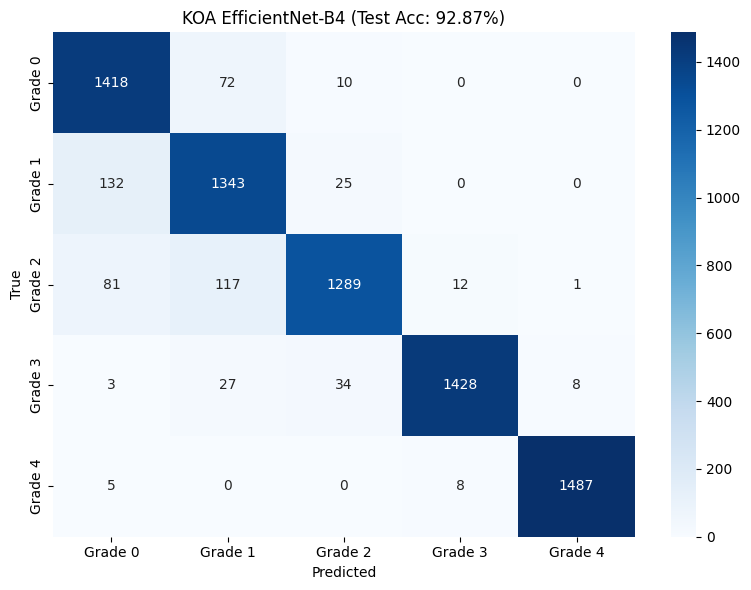

              precision    recall  f1-score   support

     Grade 0     0.8652    0.9453    0.9035      1500
     Grade 1     0.8614    0.8953    0.8781      1500
     Grade 2     0.9492    0.8593    0.9020      1500
     Grade 3     0.9862    0.9520    0.9688      1500
     Grade 4     0.9940    0.9913    0.9927      1500

    accuracy                         0.9287      7500
   macro avg     0.9312    0.9287    0.9290      7500
weighted avg     0.9312    0.9287    0.9290      7500



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=grade_names, yticklabels=grade_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"KOA EfficientNet-B4 (Test Acc: {test_acc:.2f}%)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=grade_names, digits=4))

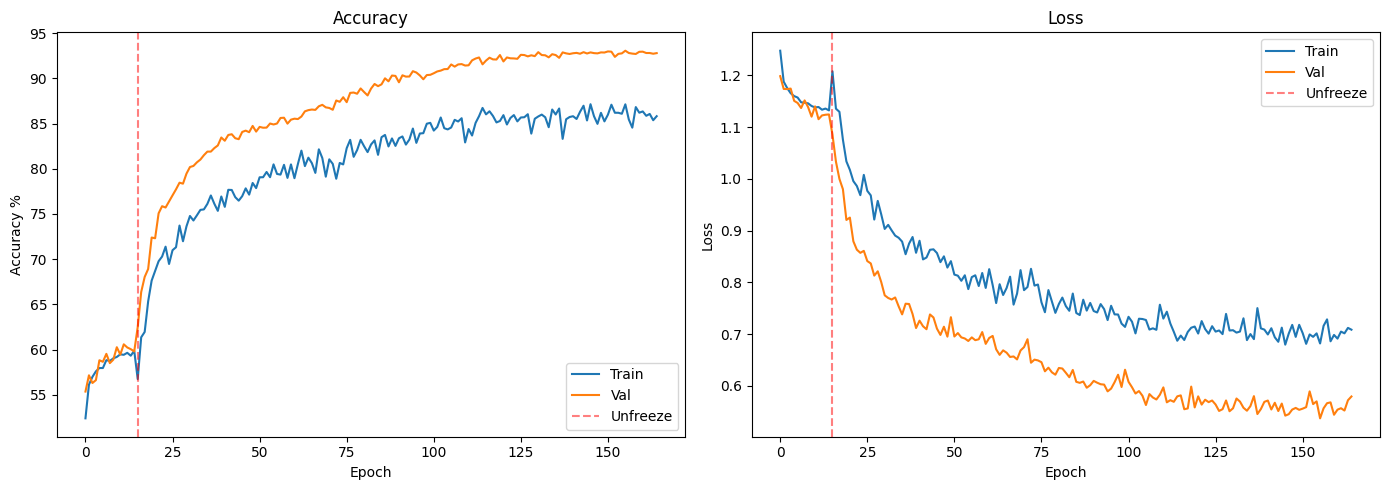

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_acc"], label="Train")
ax1.plot(history["val_acc"], label="Val")
ax1.axvline(x=CONFIG["epochs_stage1"], color="red", linestyle="--", alpha=0.5, label="Unfreeze")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy %")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(history["train_loss"], label="Train")
ax2.plot(history["val_loss"], label="Val")
ax2.axvline(x=CONFIG["epochs_stage1"], color="red", linestyle="--", alpha=0.5, label="Unfreeze")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()